<a href="https://colab.research.google.com/github/Yara-1425/NLP_Sentiment__Analysis/blob/main/LAST_Sentiment__Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Imports**

In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import os
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer


## **Data** **Loading**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/NLP_Project/IMDB Dataset.csv'

if os.path.exists(path):
    df = pd.read_csv(path)
    print("Dataset loaded successfully.")
else:
    print(f"Error: The file '{path}' was not found.")
    print("Please ensure the file 'IMDB Dataset.csv' is located at '/content/drive/MyDrive/NLP_Project/' in your Google Drive.")
    print("Alternatively, you can upload the file directly to your Colab environment or update the 'path' variable to the correct location.")
    # Initialize df to an empty DataFrame to prevent downstream errors if not found
    df = pd.DataFrame()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.


## **EDA**

In [ ]:
print("First 5 rows:")
display(df.head())

print("Shape:", df.shape)

print("Columns:", df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nStatistics:")
display(df.describe())

print("\nLabel distribution:")
print(df['sentiment'].value_counts())

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Shape: (50000, 2)
Columns: Index(['review', 'sentiment'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Missing values:
review       0
sentiment    0
dtype: int64

Duplicates:
418

Statistics:


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000



Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **cleaning**

In [ ]:
import re
import string

# df = df.dropna()

df = df.drop_duplicates()

print("\nDuplicates:")
print(df.duplicated().sum())


Duplicates:
0


In [ ]:
print("\nLabel distribution:")
print(df['sentiment'].value_counts())


Label distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [ ]:
def clean_text(text):

    text = text.lower()   # تحويل النص إلى حروف صغيرة

    text = re.sub(r'http\S+|www\S+', '', text)   # حذف الروابط

    text = text.translate(str.maketrans('', '', string.punctuation))  # حذف علامات الترقيم

    text = re.sub(r'[^\w\s]', '', text)   # حذف الرموز الخاصة

    text = re.sub(r'\s+', ' ', text).strip()   # حذف المسافات الزائدة

    return text

In [ ]:
df['cleaned_review'] = df['review'].apply(clean_text)
df.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...


In [ ]:
print("Before Cleaning:")
print(df['review'].iloc[0])

print("\nAfter Cleaning:")
print(df['cleaned_review'].iloc[0])

Before Cleaning:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

## **tokenization and stopwords removal**

In [ ]:
# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words_list = set(stopwords.words('english'))
negation_words = {'not', 'no', 'never', 'neither', 'nor', 'but', 'however',
                  "didn't", "wasn't", "weren't", "haven't", "hasn't", "won't", "hadn't"}

custom_stop_words = list(stop_words_list - negation_words)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Ayah's Processing Function (Tokenization & Stopwords Removal)
def ayah_processing(text):
    tokens = word_tokenize(str(text))
    # Filter: remove stopwords and keep only alphabetic words
    return [w for w in tokens if w not in custom_stop_words and w.isalpha()]

# Apply processing to the dataframe
df['tokenized_nonstopwords_text'] = df['cleaned_review'].apply(ayah_processing)

# Success message and output
print(f"Successfully processed by Ayah!")
display(df.head())

Successfully processed by Ayah!


,review,sentiment,cleaned_review,tokenized_nonstopwords_text
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...,"[wonderful, little, production, br, br, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, family, little, boy, jake,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, time, money, visually,..."


## **Stemming and Lemmatization**

In [ ]:
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

# تحميل البيانات الضرورية للمكتبة
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Stemming
def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

# Lemmatization
def apply_lemmatizing(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# تجربة على عينة صغيرة
df_small = df.head(100).copy()
df_small['stemmed_text'] = df_small['tokenized_nonstopwords_text'].apply(apply_stemming)
df_small['lemmatized_text'] = df_small['tokenized_nonstopwords_text'].apply(apply_lemmatizing)
display(df_small.head())

,review,sentiment,cleaned_review,tokenized_nonstopwords_text,stemmed_text,lemmatized_text
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...","[one, review, mention, watch, oz, episod, youl...","[one, reviewer, mentioned, watching, oz, episo..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...,"[wonderful, little, production, br, br, filmin...","[wonder, littl, product, br, br, film, techniq...","[wonderful, little, production, br, br, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, family, little, boy, jake,...","[basic, there, famili, littl, boy, jake, think...","[basically, there, family, little, boy, jake, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, time, money, visually,...","[petter, mattei, love, time, money, visual, st...","[petter, matteis, love, time, money, visually,..."


In [ ]:
from tqdm import tqdm
tqdm.pandas()
print("بدء عملية الـ Stemming...")
df['Stemming_text'] = df['tokenized_nonstopwords_text'].progress_apply(apply_stemming)

print("بدء عملية الـ Lemmatization ")
df['Lemmatization_text'] = df['tokenized_nonstopwords_text'].progress_apply(apply_lemmatizing)

print("تمت المعالجة بنجاح لجميع البيانات!")
display(df.head())

بدء عملية الـ Stemming...


100%|██████████| 49582/49582 [02:10<00:00, 379.37it/s]


بدء عملية الـ Lemmatization 


100%|██████████| 49582/49582 [00:38<00:00, 1289.71it/s]

تمت المعالجة بنجاح لجميع البيانات!


,review,sentiment,cleaned_review,tokenized_nonstopwords_text,Stemming_text,Lemmatization_text
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...","[one, review, mention, watch, oz, episod, youl...","[one, reviewer, mentioned, watching, oz, episo..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...,"[wonderful, little, production, br, br, filmin...","[wonder, littl, product, br, br, film, techniq...","[wonderful, little, production, br, br, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, family, little, boy, jake,...","[basic, there, famili, littl, boy, jake, think...","[basically, there, family, little, boy, jake, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, time, money, visually,...","[petter, mattei, love, time, money, visual, st...","[petter, matteis, love, time, money, visually,..."


## **Vectorization**

In [ ]:
#Bag Of Words
df['Lemmatization_text'] = df['Lemmatization_text'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else x)
df = df[df['Lemmatization_text'].notna()]
df = df[df['Lemmatization_text'].str.strip() != '']
vectorizer = CountVectorizer(
    max_features=5000,
    token_pattern=r"(?u)\b\w+\b")
features_cv = vectorizer.fit_transform(df['Lemmatization_text'])
print(features_cv.shape)
print("Sparse Matrix:\n")
print(features_cv)
#only desplay 5 rows "Avoid RAM crash"
sample_df = pd.DataFrame(
    features_cv[:5].toarray(),
    columns=vectorizer.get_feature_names_out())
display(sample_df)

(49582, 5000)
Sparse Matrix:

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4008242 stored elements and shape (49582, 5000)>
  Coords	Values
  (0, 3075)	1
  (0, 3673)	1
  (0, 2767)	1
  (0, 4829)	2
  (0, 3128)	5
  (0, 1460)	2
  (0, 4991)	1
  (0, 2110)	1
  (0, 3692)	2
  (0, 1505)	1
  (0, 1985)	1
  (0, 2748)	1
  (0, 498)	3
  (0, 1688)	2
  (0, 4459)	1
  (0, 4248)	2
  (0, 541)	1
  (0, 3817)	1
  (0, 4761)	4
  (0, 3905)	1
  (0, 4937)	1
  (0, 1875)	2
  (0, 4607)	1
  (0, 3008)	3
  (0, 3964)	4
  :	:
  (49581, 4950)	1
  (49581, 1600)	2
  (49581, 2137)	1
  (49581, 4605)	1
  (49581, 680)	1
  (49581, 3804)	1
  (49581, 2456)	1
  (49581, 4666)	1
  (49581, 2526)	1
  (49581, 1530)	1
  (49581, 302)	1
  (49581, 1994)	1
  (49581, 2217)	1
  (49581, 2195)	1
  (49581, 242)	1
  (49581, 4585)	1
  (49581, 2443)	1
  (49581, 4142)	1
  (49581, 3618)	1
  (49581, 581)	1
  (49581, 2979)	1
  (49581, 684)	1
  (49581, 1890)	1
  (49581, 3616)	1
  (49581, 2888)	1


,aaron,abandoned,abc,ability,able,aboutbr,absence,absent,absolute,absolutely,...,youd,youll,young,younger,youre,youth,youve,zero,zombie,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=10000,
    min_df=5,
    max_df=0.8)
features_tfidf = vectorizer.fit_transform(df['Lemmatization_text'])
print(features_tfidf.shape)
print("Sparse Matrix:\n")
print(features_tfidf)
#only desplay 5 rows "Avoid RAM crash"
sample_df = pd.DataFrame(
    features_tfidf[:5].toarray(),
    columns=vectorizer.get_feature_names_out())
display(sample_df)

(49582, 10000)
Sparse Matrix:

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4891624 stored elements and shape (49582, 10000)>
  Coords	Values
  (0, 6430)	0.020293893813607033
  (0, 7536)	0.0654571443415019
  (0, 5574)	0.06384866669003648
  (0, 9598)	0.07503632859045754
  (0, 6616)	0.43232419861043186
  (0, 2894)	0.10318109336851695
  (0, 9960)	0.05279643075348642
  (0, 4292)	0.08081832543279117
  (0, 7563)	0.08277644508219215
  (0, 3022)	0.055873697299012016
  (0, 4100)	0.0559606669483637
  (0, 5540)	0.07410469394688085
  (0, 929)	0.05963400238153149
  (0, 3481)	0.062025415963939824
  (0, 8887)	0.031508916664545146
  (0, 8559)	0.1617362998453165
  (0, 1188)	0.08988017143012636
  (0, 7776)	0.030442563663873764
  (0, 9456)	0.22897591154579403
  (0, 7986)	0.042387055702480456
  (0, 9798)	0.04883992938666984
  (0, 3849)	0.06506534589493873
  (0, 9192)	0.07057888501480963
  (0, 6211)	0.05857084420836328
  (0, 8076)	0.13999888928877677
  :	:
  (49581, 4482)	0.094298368395690

,aaron,abandon,abandoned,abbott,abc,ability,able,able get,able see,aboard,...,youve,youve ever,youve got,youve never,youve seen,zero,zombie,zombie movie,zone,zoom
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.100098,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


## **Feature** **Engineering**

In [ ]:
import pandas as pd
import numpy as np
import string

# 1. Text length (Character count from original Review)
df['text_len'] = df['review'].apply(len)

# 2. Word count (From original Review)
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

# 4. Punctuation count (From original Review)
df['punct_count'] = df['review'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

df['has_negation'] = df['review'].apply(lambda x: 1 if 'not' in x.lower() else 0)

print("New Numerical Features (First 5 rows):")
display(df[['text_len', 'word_count',  'punct_count', 'has_negation']].head())

New Numerical Features (First 5 rows):


,text_len,word_count,punct_count,has_negation
0,1761,307,78,1
1,998,162,44,1
2,926,166,40,1
3,748,138,42,0
4,1317,230,56,1


In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer


nltk.download('vader_lexicon', quiet=True)

True

In [ ]:
sia = SentimentIntensityAnalyzer()

df['pos_score'] = df['review'].apply(lambda x: sia.polarity_scores(x)['pos'])
df['neg_score'] = df['review'].apply(lambda x: sia.polarity_scores(x)['neg'])

print(df[['pos_score', 'neg_score']].head())

   pos_score  neg_score
0      0.048      0.203
1      0.172      0.053
2      0.192      0.094
3      0.065      0.138
4      0.147      0.052


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

# Initialize MinMaxScaler to normalize features between 0 and 1
scaler = MinMaxScaler()
new_meta_features = scaler.fit_transform(df[['text_len', 'word_count', 'punct_count', 'has_negation']])

# Combine Sparse TF-IDF Matrix with the new Scaled Meta-features
# Using hstack to prevent RAM crash
final_features = hstack([
    features_tfidf,
    new_meta_features,
    df['pos_score'].values.reshape(-1, 1), # Reshape to a column vector
    df['neg_score'].values.reshape(-1, 1)  # Reshape to a column vector
])

print("Final Matrix Details:")
print(f"Original TF-IDF Shape: {features_tfidf.shape}")
print(f"Final Combined Shape: {final_features.shape}")
print("\nSuccess: Features are now ready for model training.")

Final Matrix Details:
Original TF-IDF Shape: (49582, 10000)
Final Combined Shape: (49582, 10006)

Success: Features are now ready for model training.


## **Model Training**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Split the data into training and testing sets
X= final_features
Y=df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (39665, 10006)
Shape of X_test: (9917, 10006)
Shape of y_train: (39665,)
Shape of y_test: (9917,)


In [ ]:
# Initialize and train the Logistic Regression model
print("Training Logistic Regression model...")
model_l = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model_l.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_l = model_l.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_l):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_l))

Training Logistic Regression model...
Training complete.

Model Evaluation:
Accuracy: 0.8922
Classification Report:
               precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4940
    positive       0.89      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the SVM model
print("Training SVM model...")

model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Training SVM model...
Training complete.

Model Evaluation:
Accuracy: 0.8925
Classification Report:
               precision    recall  f1-score   support

    negative       0.90      0.89      0.89      4940
    positive       0.89      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



## **Model Training 2**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:


# 1. Data Preparation
X = final_features
y = df['sentiment']
# Splitting the data (80% train, 20% test)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Initialize and Train the Random Forest Model
print("Initializing Random Forest...")
# n_estimators=100 means the model will build 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training Model 2...")
rf_model.fit(X_train2, y_train2)
print("Training Complete.")

# 3. Model Evaluation
y_pred2 = rf_model.predict(X_test2)

print("\n--- Random Forest Evaluation Results ---")
print(f"Accuracy Score: {accuracy_score(y_test2, y_pred2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred2))

Initializing Random Forest...
Training Model 2...
Training Complete.

--- Random Forest Evaluation Results ---
Accuracy Score: 0.8515

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4940
    positive       0.85      0.85      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



## **K-Fold**

In [ ]:
from sklearn.model_selection import cross_val_score

# k-fold
print("Running 5-fold Cross-Validation...")
cv_scores = cross_val_score(model_l, X, Y, cv=5)

print(f"Scores for each fold: {cv_scores}")
print(f"Average Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Running 5-fold Cross-Validation...
Scores for each fold: [0.89704548 0.89452455 0.8932029  0.89219443 0.89753933]
Average Accuracy: 0.8949
Standard Deviation: 0.0021


## **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

print("Searching for the best hyperparameters...")
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score from Grid Search: {grid_search.best_score_:.4f}")

y_pred_optimized = best_model.predict(X_test)
print("\nOptimized Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")

Searching for the best hyperparameters...
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score from Grid Search: 0.8929

Optimized Model Evaluation:
Accuracy: 0.8922


## **Confusion Matrix**

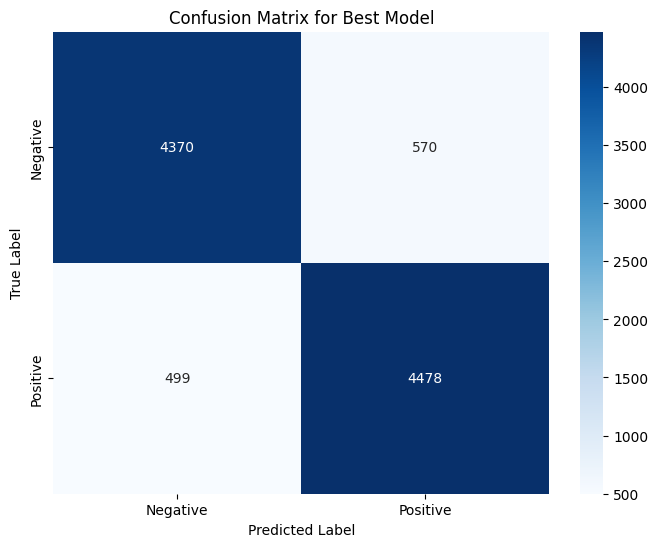

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_l)

#Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix for Best Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **Error Analysis**

In [ ]:
import pandas as pd

y_pred_all = model_l.predict(final_features)

results_df = pd.DataFrame({
    'Review': df['cleaned_review'],
    'True_Sentiment':df['sentiment'] ,
    'Predicted_Sentiment': y_pred_all
})


errors_df = results_df[results_df['True_Sentiment'] != results_df['Predicted_Sentiment']]

print("Error Analysis Results:")
errors_df.head(10)

Error Analysis Results:


,Review,True_Sentiment,Predicted_Sentiment
16,some films just simply should not be remade th...,positive,negative
30,taut and organically gripping edward dmytryks ...,positive,negative
52,bela lugosi appeared in several of these low b...,positive,negative
67,i really like salman kahn so i was really disa...,negative,positive
71,honestly this short film sucks the dummy used ...,negative,positive
72,i thought that mukhsin has been wonderfully wr...,positive,negative
76,the last hard men finds james coburn an outlaw...,positive,negative
94,i watched this series out of curiositywanting ...,negative,positive
103,no this hilariously horrible 70s madefortv hor...,positive,negative
122,a bored television director is introduced to t...,negative,positive


# **NEED Contextual Understanding**